## Graphical abstract

UMAP + cluster-coloring and pie-chart plots used for the paper's graphical abstract,
extracted from `figure_5_main`. Run the imports + data-loading cells first.

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [54]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Clustering results, coding scores, UMAP

In [55]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


### Graphical abstract

In [56]:
import umap

In [57]:
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [58]:
# limit cluster meta to cells that are not in cluster 1 (which is an outlier in the plot)
main_cluster_meta = cluster_meta[cluster_meta.cluster_id!=1]
# limit umap_df to non-cluster 1
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')
umap_df = umap_df.loc[main_cluster_meta.index.values]
umap_df['cell_type'] = main_cluster_meta['cell_type']
# identify other non-outlier points and limit both tables to those
csids = umap_df[umap_df.x<16].index.values
main_cluster_meta = main_cluster_meta.loc[csids]
umap_df = umap_df.loc[csids]
print(len(umap_df), len(main_cluster_meta))
umap_df.head()

2941 2941


,x,y,cluster_id,cell_type
cell_specimen_id,,,,
1086489847,4.780380,7.625232,12,Vip Inhibitory
1086489860,9.371953,2.737884,2,Vip Inhibitory
1086489891,4.785028,7.619345,12,Vip Inhibitory
1086489976,6.144250,11.332527,4,Sst Inhibitory
1086490002,9.028252,10.901272,4,Sst Inhibitory


In [59]:
exp_colors = utils.get_experience_level_colors()
gray = (0.8, 0.8, 0.8)
cluster_color_dict = {1: gray, # non coding - gray
                      2: exp_colors[1], # novel image coding - red
                      3: exp_colors[2], # persistent novel image coding - purple 
                      4: exp_colors[0], # familiar image coding - blue
                      5: exp_colors[2], # novel+ image coding - purple 
                      6: exp_colors[2], # novelty suppression - purple
                      7: exp_colors[1], # novel image (+familiar) coding - red
                      8: exp_colors[0], # omission coding during familiar - blue
                      9: exp_colors[2], # omission coding during novel+ - purple
                      10: exp_colors[0], # task coding during familiar - blue
                      11: exp_colors[1], # novel task coding - red
                      12: gray, # behavior coding - gray
                      }
exp_colors = [cluster_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


feature_colors = plotting.get_feature_colors_with_gray()
feature_color_dict = {1: gray, # non coding - gray
                      2: feature_colors[1], # image coding
                      3: feature_colors[1], # image coding
                      4: feature_colors[1], # image coding
                      5: feature_colors[1], # image coding 
                      6: feature_colors[1], # image coding 
                      7: feature_colors[1], # image coding 
                      8: feature_colors[2], # omission coding
                      9: feature_colors[2], # omission coding
                      10: feature_colors[3], # task coding
                      11: feature_colors[3], # task coding
                      12: feature_colors[4], # behavior coding
                      }

feature_colors = [feature_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

meaningful_labels_dict = {1: '', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red
                3: 'novel image coding', # persistent novel image coding - purple 
                4: 'familiar image coding', # familiar image coding - blue
                5: '', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - purple
                7: '', # everything coding gray
                8: 'omission coding', # omission coding during familiar - blue
                9: 'omission coding', # omission coding during novel+ - purple
                10: 'task coding', # task coding during familiar - blue
                11: '', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - gray
                }
meaningful_labels = [meaningful_labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

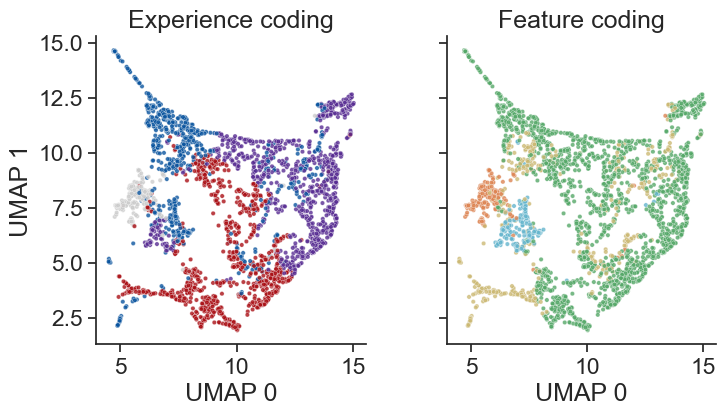

In [60]:
figsize = (8, 4)

fig, ax = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

umap_df['labels'] = meaningful_labels
ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')
plt.subplots_adjust(wspace=0.3)

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_8385/1807117366.py:23: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,


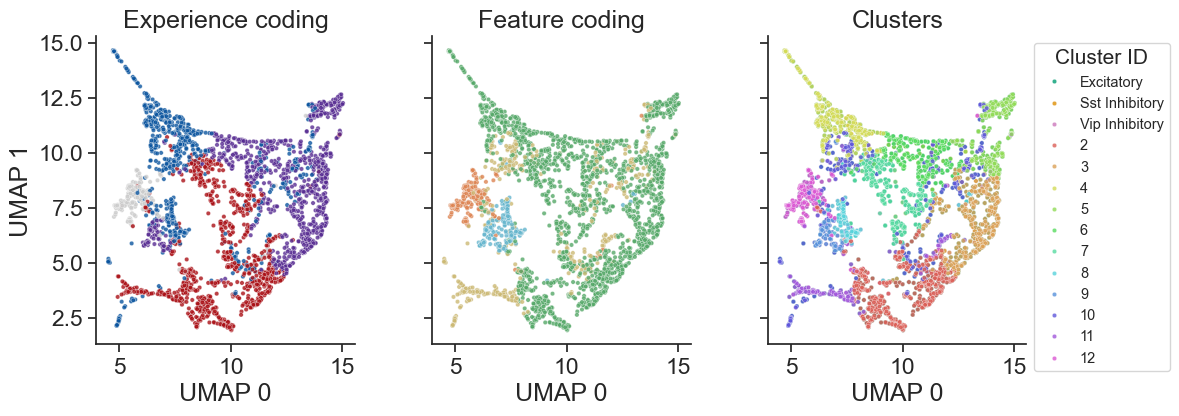

In [61]:
figsize = (12, 4)

fig, ax = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], hue_order=cell_types,
                     hue='cell_type', markers=markers, palette=utils.get_cell_type_colors(), alpha=0.8)
ax[2].set_title('Cell types')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cell type', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,
                     hue='cluster_id', markers=markers, palette=sns.color_palette('hls', 12), alpha=0.8)
ax[2].set_title('Clusters')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cluster ID', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

#### Try with new colors for specific cluster types

In [62]:
cluster_id_labels = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


# gray = #BFBFBF
clutster_colors_dict = {1: '#BFBFBF', # non coding - gray #BFBFBF
                2: '#AB0F15', # novel image coding - red #AB0F15
                3: '#A2258F', # persistent novel image coding -  reddish purple #A2258F
                4: '#0B549D', # familiar image coding - blue #0B549D
                5: '#BFBFBF', # weird coding - gray
                6: '#E38686', # novelty suppression - light red #E38686
                7: '#BFBFBF', # everything coding gray
                8: '#71A9DE', # omission coding during familiar - light blue #71A9DE
                9: '#9A79C9', # omission coding during novel+ - light purple #9A79C9
                10: '#DBD689', # task coding during familiar - yellow #DBD689
                11: '#BFBFBF', # task coding during novel - gray
                12: '#FAB171', # behavior coding - orange #FAB171
                }
new_colors = [clutster_colors_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

In [63]:
umap_df['cluster_id'] = [main_cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in main_cluster_meta.cell_type.values]
umap_df.head()

,x,y,cluster_id,cell_type,labels,cluster_label
cell_specimen_id,,,,,,
1086489847,4.780380,7.625232,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489860,9.371953,2.737884,cluster 2,Vip Inhibitory,novelty enhanced,novelty enhanced
1086489891,4.785028,7.619345,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489976,6.144250,11.332527,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding
1086490002,9.028252,10.901272,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding


In [64]:
red = sns.color_palette('Reds_r', 6).as_hex()[0]
blue = sns.color_palette('Blues_r', 6).as_hex()[0]
purple = sns.color_palette('Purples_r', 6).as_hex()[0]
print(red, blue, purple)

red = sns.color_palette('Reds_r', 6).as_hex()[2]
blue = sns.color_palette('Blues_r', 6).as_hex()[2]
purple = sns.color_palette('Purples_r', 6).as_hex()[2]
print(red, blue, purple)

#aa1016 #0b559f #572c92
#f44f39 #539ecd #8d89c0


In [65]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF



Text(0.5, 1.0, 'Main clusters')

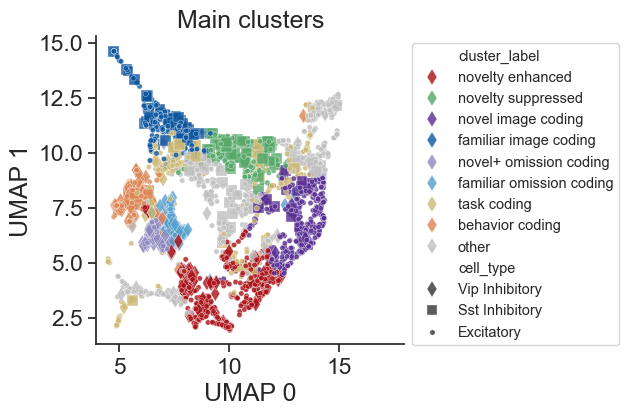

In [66]:
figsize = (7, 4)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_label', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Main clusters')

#### pie charts

In [67]:
labels_dict = {1: 'non-coding', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'novel image coding', # weird coding -reddish purple
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'unselective', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'task coding', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


In [68]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF', # unselective
            '#BFBFBF',] # non-coding - gray #BFBFBF


In [69]:
# get saved umap results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')

umap_df['cluster_id'] = [cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in cluster_meta.cell_type.values]
umap_df.head()

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


,x,y,cluster_id,cluster_label,cell_type
cell_specimen_id,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,Sst Inhibitory


In [70]:
cluster_counts = umap_df.groupby(['cell_type', 'cluster_label']).count().rename(columns={'cluster_id':'n_cluster'})[['n_cluster']].reset_index()
cre_counts = umap_df.groupby(['cell_type']).count().rename(columns={'cluster_id':'n_cre'})[['n_cre']].reset_index()
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster']/counts['n_cre']
counts

,cell_type,cluster_label,n_cluster,n_cre,fraction
0,Excitatory,behavior coding,128,3298,0.038811
1,Excitatory,familiar image coding,313,3298,0.094906
2,Excitatory,familiar omission coding,25,3298,0.007580
3,Excitatory,non-coding,722,3298,0.218921
4,Excitatory,novel image coding,687,3298,0.208308
5,Excitatory,novel+ omission coding,29,3298,0.008793
6,Excitatory,novelty enhanced,611,3298,0.185264
7,Excitatory,novelty suppressed,177,3298,0.053669
8,Excitatory,task coding,402,3298,0.121892
9,Excitatory,unselective,204,3298,0.061856


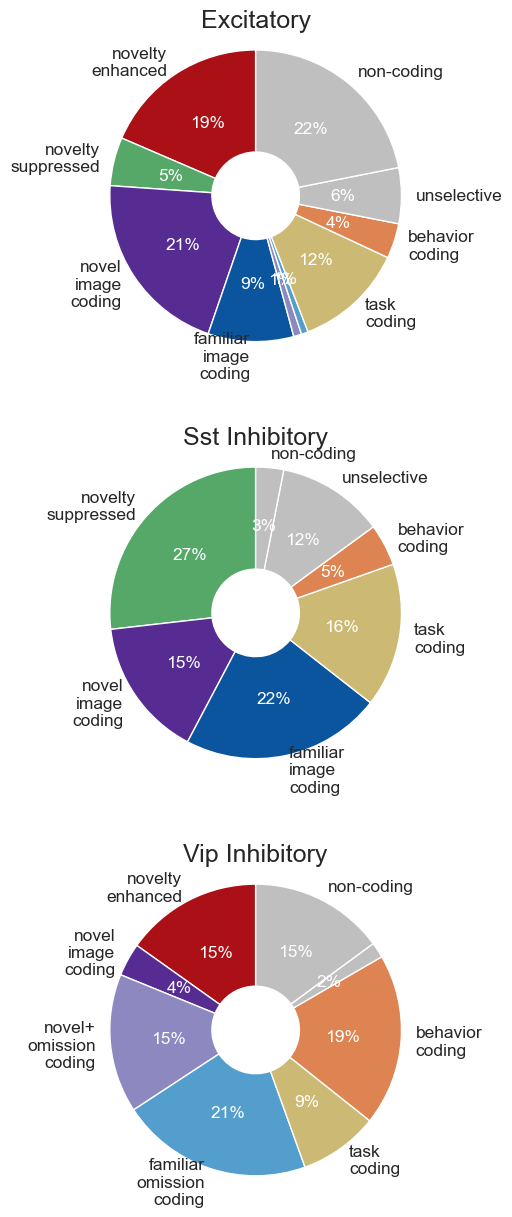

In [71]:
figsize = (5, 15)
fig, ax = plt.subplots(3, 1, figsize=figsize)

for i, cell_type in enumerate(cell_types): 
    # get data for this cell type, with cluster labels & colors in a specific order
    data = counts[counts.cell_type==cell_type]
    fractions = []
    colors = []
    cluster_labels = []
    for c, cluster_label in enumerate(hue_order): 
        tmp = data[data.cluster_label==cluster_label]
        if len(tmp)>0: 
            fractions.append(tmp.fraction.values[0])
            colors.append(palette[c])
            if tmp.fraction.values[0]<=0.03: 
                label = ''
            else: 
                label = cluster_label.replace(' ','\n')
            cluster_labels.append(label)

    # plot it 
    wedges, texts, autotexts = ax[i].pie(fractions, 
                                        labels=cluster_labels, 
                                        autopct='%.0f%%',
                                        startangle=90, 
                                        wedgeprops={'width': 0.7, 'edgecolor': 'white'},   
                                        textprops={'size': 'x-small'},
                                        colors=colors) # Use a Seaborn color palette
    ax[i].axis('equal') 
    ax[i].set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

    # Equal aspect ratio ensures that pie is drawn as a circle.
plt.subplots_adjust(hspace=0.3)

### Cluster average-response traces — data load

Loads per-cell mean event responses (change- and omission-aligned) used for the small per-cluster trace insets around the UMAP, exactly as in `figure_5_main`. Slow; cached via a `globals()` guard so re-running the composite doesn't reload.

In [72]:
# ---- data for cluster average-response traces (loaded once; slow) ----
if ('change_mdf' not in globals()) or ('omission_mdf' not in globals()):
    _dt, _interp, _osr, _incl = 'events', True, 30, 'platform_experiment_table'
    _msdf = loading.get_multi_session_df_for_conditions(
        _dt, event_type='all', conditions=['cell_specimen_id', 'is_change'],
        inclusion_criteria=_incl, interpolate=_interp, output_sampling_rate=_osr, epoch_duration_mins=None)
    _clu = cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']]
    change_mdf = _msdf[_msdf.is_change == True].merge(_clu, on='cell_specimen_id')
    image_mdf  = _msdf[_msdf.is_change == False].merge(_clu, on='cell_specimen_id')
    omission_mdf = loading.get_multi_session_df_for_conditions(
        _dt, event_type='all', conditions=['cell_specimen_id', 'omitted'],
        inclusion_criteria=_incl, interpolate=_interp, output_sampling_rate=_osr, epoch_duration_mins=None)
    omission_mdf = omission_mdf[omission_mdf.omitted == True].merge(_clu, on='cell_specimen_id')
    _thr = 99.9
    image_mdf, _    = processing.remove_outliers(image_mdf, _thr)
    change_mdf, _   = processing.remove_outliers(change_mdf, _thr)
    omission_mdf, _ = processing.remove_outliers(omission_mdf, _thr)
    print('loaded change_mdf', change_mdf.shape, '| omission_mdf', omission_mdf.shape)
else:
    print('change_mdf / omission_mdf already loaded; skipping reload')


change_mdf / omission_mdf already loaded; skipping reload


### Composite figure for graphical abstract

Combines the two data elements from this notebook — the **UMAP cluster scatter**
("Main clusters", cell above) and the **cell-type pie charts** — into a single
figure laid out like the bottom section of slide 1 of *VBO figures - revised v6*:
large UMAP on the left, the three cell-type pies stacked vertically on the right.
No panel letters (graphical-abstract style). Trace insets, the neuron schematic,
and the section title on the slide are added separately in PowerPoint.

Self-contained: rebuilds both the scatter table (cluster-1 + far outliers removed,
scatter label scheme) and the pie counts (full population, pie label scheme) from
`cluster_meta`, so it does not depend on whichever `umap_df` survived the cells above.
Layout knobs are constants at the top of the cell.

In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ---------------- layout knobs (tweak between renders) ----------------
FIGSIZE          = (13, 7.2)
WIDTH_RATIOS     = (2.2, 1.0)   # UMAP : pie column
PIE_WSPACE       = 0.28         # gap between UMAP and pie column (larger -> pies further right)
PIE_HSPACE       = 0.35         # (gridspec spacing; overridden by manual pie packing below)
PIE_GAP          = 0.06         # gap between packed pies (fig-fraction; includes title room)
PIE_TITLE_FS     = 16           # pie title font size
UMAP_MARKER_SIZE = 60
LEGEND_BBOX      = (0.81, 0.0)  # legend anchor (loc='lower left'): bottom aligned to UMAP bottom
LEGEND_MARKERSIZE = 11          # legend swatch size (does NOT affect plot markers)
SHOW_SCHEMATIC   = False        # hide cell-type schematic (kept for later); legend now carries cell-type symbols
# cell-type schematic is placed RELATIVE to the legend (centered just above its rendered bbox)
SCHEM_W          = 0.42   # schematic inset width  (UMAP axes-fraction) -> bigger cells
SCHEM_H          = 0.26   # schematic inset height (UMAP axes-fraction)
SCHEM_GAP        = 0.119  # vertical gap above the legend
SCHEM_DX         = -0.042 # horizontal nudge from legend center (+right / -left)
SCHEM_VIP_DY     = 0.24   # raise the Vip cell so its lower process clears the 'Vip' label
SCHEM_EXC_SCALE  = 1.28         # Excitatory triangle a bit bigger than Vip/Sst
SCHEM_GRAY       = '#7d7d7d'
SCHEM_R          = 0.30   # schematic cell-body radius (inset data units)
SCHEM_PLEN       = 0.55   # main process length
SCHEM_LW         = 2.2    # process line width
LEGEND_FONTSIZE  = 'small'      # legend text/title size
pie_cell_types   = ['Excitatory', 'Sst Inhibitory', 'Vip Inhibitory']  # top -> bottom

# ---------------- per-cluster average-response trace insets ----------------
SHOW_TRACES = True            # False -> hide the little cluster traces
TRACE_W     = 0.15            # trace inset width  (UMAP axes-fraction)
TRACE_H     = 0.11            # trace inset height (UMAP axes-fraction)
TRACE_RADIAL = 0.16          # auto push each trace outward from the UMAP center (axes-fraction)
# which clusters get a trace, alignment ('change' -> stim bar / 'omission' -> dashed line),
# and an optional manual nudge (dx, dy) in axes-fraction from the cluster's UMAP centroid.
TRACE_CONFIG = {  # dx/dy in axes-fraction; ~TRACE_W (0.15) per plot-width, ~TRACE_H (0.11) per plot-height
    2:  dict(align='change',   dx=+0.18,  dy=+0.055), # novelty enhanced      -> left 50%, down 30%
    3:  dict(align='change',   dx=-0.075, dy=-0.127), # novel image coding    -> right 30%, up 15%
    4:  dict(align='change',   dx=+0.225, dy=-0.055), # familiar image coding -> (kept)
    6:  dict(align='change',   dx=0.0,    dy=0.0),    # novelty suppressed    -> (kept)
    8:  dict(align='omission', dx=-0.143, dy=+0.187), # familiar omission     -> (kept)
    9:  dict(align='omission', dx=-0.068, dy=+0.088), # novel+ omission       -> left 5%, up 5%
    11: dict(align='change',   dx=+0.03,  dy=-0.055), # novel task coding     -> left 10%, up 10%
}

# ---------------- scatter label scheme (cells 16/19) ----------------
scatter_labels_dict = {1: 'non-coding / unselective', 2: 'novelty enhanced', 3: 'novel image coding',
                       4: 'familiar image coding', 5: 'novel image coding', 6: 'novelty suppressed',
                       7: 'non-coding / unselective', 8: 'familiar omission coding', 9: 'novel+ omission coding',
                       10: 'familiar task coding', 11: 'novel task coding', 12: 'behavior coding'}
scatter_hue_order = ['novelty enhanced', 'novelty suppressed', 'novel image coding',
                     'familiar image coding', 'novel+ omission coding', 'familiar omission coding',
                     'novel task coding', 'familiar task coding', 'behavior coding', 'non-coding / unselective']
scatter_palette = ['#aa1016', '#55a868', '#572c92', '#0b559f', '#8d89c0', '#539ecd',
                   '#e3bbcd', '#ccb974', '#dd8452', '#BFBFBF']
markers_dict = {'Excitatory': '.', 'Sst Inhibitory': 's', 'Vip Inhibitory': 'd'}  # original: point=Exc, square=Sst, diamond=Vip

# ---------------- pie label scheme (cells 22/23) ----------------
pie_labels_dict = {1: 'non-coding / unselective', 2: 'novelty enhanced', 3: 'novel image coding',
                   4: 'familiar image coding', 5: 'novel image coding', 6: 'novelty suppressed',
                   7: 'non-coding / unselective', 8: 'familiar omission coding', 9: 'novel+ omission coding',
                   10: 'familiar task coding', 11: 'novel task coding', 12: 'behavior coding'}
pie_hue_order = ['novelty enhanced', 'novelty suppressed', 'novel image coding',
                 'familiar image coding', 'novel+ omission coding', 'familiar omission coding',
                 'novel task coding', 'familiar task coding', 'behavior coding', 'non-coding / unselective']
pie_palette = ['#aa1016', '#55a868', '#572c92', '#0b559f', '#8d89c0', '#539ecd',
               '#e3bbcd', '#ccb974', '#dd8452', '#BFBFBF']

# ---------------- rebuild scatter table (filtered; cells 11-19) ----------------
scatter_umap = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
scatter_umap['cell_specimen_id'] = cluster_meta.index.values
scatter_umap = scatter_umap.set_index('cell_specimen_id')
_meta = cluster_meta[cluster_meta.cluster_id != 1]          # drop non-coding outlier cluster
scatter_umap = scatter_umap.loc[_meta.index.values]
scatter_umap = scatter_umap[scatter_umap.x < 16]           # drop far outliers
_meta = _meta.loc[scatter_umap.index.values]
scatter_umap['cluster_label'] = [scatter_labels_dict[_meta.loc[csid]['cluster_id']]
                                 for csid in scatter_umap.index.values]
scatter_umap['cell_type'] = _meta['cell_type'].values
scatter_umap['cluster_id'] = _meta['cluster_id'].values   # for trace-inset centroids

# ---------------- rebuild pie counts (full population; cells 24-25) ----------------
pie_umap = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
pie_umap['cell_specimen_id'] = cluster_meta.index.values
pie_umap = pie_umap.set_index('cell_specimen_id')
pie_umap['cluster_label'] = [pie_labels_dict[cluster_meta.loc[csid]['cluster_id']]
                             for csid in cluster_meta.index.values]
pie_umap['cell_type'] = cluster_meta['cell_type'].values
cluster_counts = pie_umap.groupby(['cell_type', 'cluster_label']).size().reset_index(name='n_cluster')
cre_counts = pie_umap.groupby('cell_type').size().reset_index(name='n_cre')
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster'] / counts['n_cre']

# ---------------- figure ----------------
fig = plt.figure(figsize=FIGSIZE)
outer = gridspec.GridSpec(1, 2, width_ratios=WIDTH_RATIOS, wspace=PIE_WSPACE)
ax_umap = fig.add_subplot(outer[0, 0])
pie_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[0, 1], hspace=PIE_HSPACE)
pie_axes = [fig.add_subplot(pie_gs[i, 0]) for i in range(3)]

# UMAP scatter (mirrors the "Main clusters" cell)
sns.scatterplot(data=scatter_umap, x='x', y='y', s=UMAP_MARKER_SIZE, ax=ax_umap,
                hue='cluster_label', hue_order=scatter_hue_order,
                style='cell_type', palette=scatter_palette, markers=markers_dict,
                linewidth=0.3, alpha=0.8, edgecolor='w')
ax_umap.axis('square')
# graphical-abstract styling: no frame, ticks, or axis labels on the UMAP
ax_umap.set_xlabel(''); ax_umap.set_ylabel('')
ax_umap.set_xticks([]); ax_umap.set_yticks([])
for _sp in ax_umap.spines.values():
    _sp.set_visible(False)
# legend sits in the gap between the UMAP and the pies; it carries the cluster-label
# colors (shared by the pies) and the cell-type markers, so the pies need no labels
# legend: cell-type SHAPES on top (color-neutral gray; shape encodes cell type), then the
# cluster-label COLOR swatches below (color encodes cluster; square, shape-agnostic).
_ct_handles = [Line2D([0], [0], marker=markers_dict[_lab], linestyle='none',
                      markerfacecolor='#555555', markeredgecolor='#555555',
                      markersize=LEGEND_MARKERSIZE, label=_lab)
               for _lab in ['Excitatory', 'Sst Inhibitory', 'Vip Inhibitory']]
_cluster_handles = [Line2D([0], [0], marker='s', linestyle='none', markerfacecolor=_c,
                           markeredgecolor='none', markersize=LEGEND_MARKERSIZE, label=_lab)
                    for _lab, _c in zip(scatter_hue_order, scatter_palette)]
# both section headers are left-aligned pseudo-entries (empty handle), so they line up at the
# same left edge as the entry labels (a legend TITLE is centered and can't align there).
_ct_hdr = Line2D([0], [0], marker='None', linestyle='none', label='Cell type')
_hdr    = Line2D([0], [0], marker='None', linestyle='none', label='Functional type')
_spacer = Line2D([0], [0], marker='None', linestyle='none', label=' ')            # blank row -> whitespace
legend_handles = [_ct_hdr] + _ct_handles + [_spacer, _hdr] + _cluster_handles
_leg = ax_umap.legend(handles=legend_handles,
                      fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_FONTSIZE,
                      bbox_to_anchor=LEGEND_BBOX, loc='lower left', framealpha=0.0)
for _t in _leg.get_texts():                                   # bold both section headers
    if _t.get_text().strip() in ('Cell type', 'Functional type'):
        _t.set_fontweight('bold')

# cell-type schematic above the legend: same shapes as the scatter markers, drawn larger
# with a bit of cell anatomy. Vip = diamond w/ vertical processes (top & bottom); Sst = circle
# w/ 4 lateral dendrites; Exc = pyramidal triangle w/ apical dendrite forking into 2 branches.
def _draw_cell(ax, kind, x, y, r=SCHEM_R, L=SCHEM_PLEN, lw=SCHEM_LW):
    s2 = 0.7071; b = 0.27                      # b = apical branch length
    if kind == 'vip':                          # diamond, vertical process top & bottom
        ax.add_patch(mpatches.RegularPolygon((x, y), 4, radius=r, orientation=0,
                     facecolor=SCHEM_GRAY, edgecolor='k', lw=1.2, zorder=3))
        ax.add_line(Line2D([x, x], [y + r, y + r + L], color='k', lw=lw, zorder=2))
        ax.add_line(Line2D([x, x], [y - r, y - r - L], color='k', lw=lw, zorder=2))
    elif kind == 'sst':                        # circle, 4 diagonal lateral dendrites
        ax.add_patch(mpatches.Circle((x, y), r, facecolor=SCHEM_GRAY, edgecolor='k', lw=1.2, zorder=3))
        for _a in (45, 135, 225, 315):
            _ca, _sa = np.cos(np.radians(_a)), np.sin(np.radians(_a))
            ax.add_line(Line2D([x + r * _ca, x + (r + 0.42) * _ca],
                               [y + r * _sa, y + (r + 0.42) * _sa], color='k', lw=lw, zorder=2))
    elif kind == 'exc':                        # triangle apex-up, apical dendrite forking in 2
        r = r * SCHEM_EXC_SCALE
        ax.add_patch(mpatches.RegularPolygon((x, y), 3, radius=r, orientation=0,
                     facecolor=SCHEM_GRAY, edgecolor='k', lw=1.2, zorder=3))
        _top = y + r
        ax.add_line(Line2D([x, x], [_top, _top + L], color='k', lw=lw, zorder=2))
        _ty = _top + L
        ax.add_line(Line2D([x, x - b * s2], [_ty, _ty + b * s2], color='k', lw=lw, zorder=2))
        ax.add_line(Line2D([x, x + b * s2], [_ty, _ty + b * s2], color='k', lw=lw, zorder=2))

# little per-cluster average-response trace; pools ALL cells in the cluster (no cre_line filter).
# Mirrors plot_population_average_response_for_cluster but without the single-cre_line restriction.
def _plot_cluster_pop_avg(mdf, cluster_id, change, omitted, ax, alpha=0.15):
    _colors = utils.get_experience_level_colors()             # [Familiar, Novel, Novel+]
    _exp = np.sort(mdf['experience_level'].unique())
    _ts = mdf['trace_timestamps'].values[0]
    _xlim = [-1, 0.75] if change else [-1, 1.5]
    _sub = mdf[mdf.cluster_id == cluster_id]
    # draw back -> front so Novel (red) ends on top, then Familiar (blue), Novel+ (purple) behind.
    # _exp sorts to [Familiar, Novel, Novel+]; _colors is [Familiar=blue, Novel=red, Novel+=purple].
    for _i in [2, 0, 1]:                        # Novel+ (back), Familiar (mid), Novel (front)
        if _i >= len(_exp):
            continue
        _tr = _sub[_sub.experience_level == _exp[_i]].mean_trace.values
        if len(_tr) == 0:
            continue
        ax = utils.plot_mean_trace(np.asarray(_tr), _ts, ylabel='', legend_label=None,
                                   color=_colors[_i], interval_sec=1, plot_sem=False,
                                   xlim_seconds=_xlim, ax=ax)
    utils.plot_flashes_on_trace(ax, _ts, change=change, omitted=omitted, alpha=alpha)
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_xticks([]); ax.set_yticks([])
    for _s in ax.spines.values():
        _s.set_visible(False)
    return ax

# cell-type schematic (hidden via SHOW_SCHEMATIC; kept for later)
if SHOW_SCHEMATIC:
    # place the schematic centered just above the legend's ACTUAL rendered bbox (tracks the legend)
    fig.canvas.draw()
    _bb = _leg.get_window_extent().transformed(ax_umap.transAxes.inverted())
    _cx = (_bb.x0 + _bb.x1) / 2 + SCHEM_DX
    sax = ax_umap.inset_axes([_cx - SCHEM_W / 2, _bb.y1 + SCHEM_GAP, SCHEM_W, SCHEM_H])
    sax.patch.set_alpha(0.0)
    for _kind, _lab, _xc in zip(['vip', 'sst', 'exc'], ['Vip', 'Sst', 'Exc'], [0.7, 1.8, 2.9]):
        _yc = 1.15 + (SCHEM_VIP_DY if _kind == 'vip' else 0.0)
        _draw_cell(sax, _kind, _xc, _yc)
        sax.text(_xc, 0.18, _lab, ha='center', va='center', fontsize=13)
    sax.set_xlim(0.1, 3.5); sax.set_ylim(0.0, 2.55); sax.set_aspect('equal'); sax.axis('off')

# per-cluster average-response trace insets, auto-placed at each cluster's UMAP centroid
if SHOW_TRACES and ('change_mdf' in globals()) and ('omission_mdf' in globals()):
    _mdf_for = {'change': change_mdf, 'omission': omission_mdf}
    _cents = scatter_umap.groupby('cluster_id')[['x', 'y']].mean()
    _xl, _yl = ax_umap.get_xlim(), ax_umap.get_ylim()
    _gxf = (scatter_umap['x'].mean() - _xl[0]) / (_xl[1] - _xl[0])   # UMAP center, axes-fraction
    _gyf = (scatter_umap['y'].mean() - _yl[0]) / (_yl[1] - _yl[0])
    for _cid, _cfg in TRACE_CONFIG.items():
        if _cid not in _cents.index:
            continue
        _cxf = (_cents.loc[_cid, 'x'] - _xl[0]) / (_xl[1] - _xl[0])
        _cyf = (_cents.loc[_cid, 'y'] - _yl[0]) / (_yl[1] - _yl[0])
        _ddx, _ddy = _cxf - _gxf, _cyf - _gyf                        # outward direction from center
        _nrm = (_ddx ** 2 + _ddy ** 2) ** 0.5 or 1.0
        _oxf, _oyf = TRACE_RADIAL * _ddx / _nrm, TRACE_RADIAL * _ddy / _nrm
        _tax = ax_umap.inset_axes([_cxf - TRACE_W / 2 + _oxf + _cfg.get('dx', 0.0),
                                   _cyf - TRACE_H / 2 + _oyf + _cfg.get('dy', 0.0), TRACE_W, TRACE_H])
        _tax.patch.set_alpha(0.0)
        _align = _cfg['align']
        _plot_cluster_pop_avg(_mdf_for[_align], _cid,
                              change=(_align == 'change'), omitted=(_align == 'omission'), ax=_tax)
elif SHOW_TRACES:
    print('SHOW_TRACES=True but change_mdf/omission_mdf not loaded - run the trace data-load cell above first.')

# pies (mirrors the pie-chart cell, one cell type per row)
for ax, cell_type in zip(pie_axes, pie_cell_types):
    data = counts[counts.cell_type == cell_type]
    fractions, colors = [], []
    for c, cluster_label in enumerate(pie_hue_order):
        tmp = data[data.cluster_label == cluster_label]
        if len(tmp) > 0:
            fractions.append(tmp.fraction.values[0])
            colors.append(pie_palette[c])
    ax.pie(fractions, labels=None, autopct=None, startangle=90,
           wedgeprops={'width': 0.7, 'edgecolor': 'white'}, colors=colors)
    ax.axis('equal')
    ax.set_title(cell_type)

# pack the pie stack: keep each circle's size, drop internal whitespace, align top of first pie
# with the UMAP top (and shrink titles). Each pie box is resized to a DISPLAY square == the circle.
for _ax in pie_axes:
    _ax.title.set_fontsize(PIE_TITLE_FS)
fig.canvas.draw()
_fw, _fh = fig.get_size_inches()
_ubot = ax_umap.get_position().y0                     # UMAP bottom
_p0 = pie_axes[0].get_position()
_diam_in = min(_p0.width * _fw, _p0.height * _fh)      # current circle diameter (inches)
_wf, _hf = _diam_in / _fw, _diam_in / _fh              # square box in figure fraction
_cx = _p0.x0 + _p0.width / 2                           # keep horizontal center
_n = len(pie_axes)
for _i, _ax in enumerate(pie_axes):                   # bottom of bottom pie aligns to UMAP bottom
    _y0 = _ubot + (_n - 1 - _i) * (_hf + PIE_GAP)
    _ax.set_position([_cx - _wf / 2, _y0, _wf, _hf])

fig.savefig(os.path.join(save_dir, 'graphical_abstract_composite.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(save_dir, 'graphical_abstract_composite.pdf'), bbox_inches='tight')
plt.show()


NameError: name 'processing' is not defined